# Prova embedding

Imposta il path di un file embedding `.npy` e visualizza sei proiezioni 2D.

In [29]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer, StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"
embedding_files = sorted(EMBEDDINGS_DIR.glob("*.npy"))

print("Project root:", PROJECT_ROOT)
if embedding_files:
    print("Embedding .npy trovati:")
    for path in embedding_files:
        print("-", path.relative_to(PROJECT_ROOT))
else:
    print(f"Nessun .npy trovato in {EMBEDDINGS_DIR}")

Project root: /home/pasquale/PycharmProjects/Glomeruli-FP03-2026
Embedding .npy trovati:
- data/glomeruli/embeddings/densenet_crops_embeddings.npy
- data/glomeruli/embeddings/dinov2_base_both_embeddings.npy
- data/glomeruli/embeddings/dinov2_base_cls_embeddings.npy
- data/glomeruli/embeddings/dinov2_base_patch_embeddings.npy
- data/glomeruli/embeddings/dinov2_large_patch_embeddings.npy
- data/glomeruli/embeddings/dinov2_small_patch_embeddings.npy
- data/glomeruli/embeddings/dinov3_base_patch_crops_embeddings.npy


## Path embedding

Modifica `EMBEDDING_PATH`. Se resta vuoto, viene usato il primo `.npy` trovato in `data/glomeruli/embeddings`.

In [30]:
EMBEDDING_PATH = "data/glomeruli/embeddings/densenet_crops_embeddings.npy"  # esempio: "data/glomeruli/embeddings/nome_embedding.npy"

if EMBEDDING_PATH:
    embedding_path = Path(EMBEDDING_PATH)
    if not embedding_path.is_absolute():
        embedding_path = PROJECT_ROOT / embedding_path
elif embedding_files:
    embedding_path = embedding_files[0]
else:
    raise FileNotFoundError("Imposta EMBEDDING_PATH con il path di un file .npy.")

embeddings = np.load(embedding_path, allow_pickle=False)
embeddings = np.asarray(embeddings)

if embeddings.ndim != 2:
    raise ValueError(f"Gli embedding devono essere una matrice 2D, ricevuta shape {embeddings.shape}.")

if embeddings.shape[0] < 3:
    raise ValueError("Servono almeno 3 righe per calcolare UMAP.")

if min(embeddings.shape) < 2:
    raise ValueError(f"Servono almeno 2 feature e 2 righe, ricevuta shape {embeddings.shape}.")

if not np.all(np.isfinite(embeddings)):
    raise ValueError("Gli embedding contengono NaN o inf.")

print("File selezionato:", embedding_path)
print("Shape embeddings:", embeddings.shape)

File selezionato: /home/pasquale/PycharmProjects/Glomeruli-FP03-2026/data/glomeruli/embeddings/densenet_crops_embeddings.npy
Shape embeddings: (677, 1664)


## Proiezioni

In [31]:
N_NEIGHBORS = min(30, embeddings.shape[0] - 1)
MIN_DIST = 0.05
UMAP_METRIC = "euclidean"


def fit_umap_2d(X, metric=UMAP_METRIC):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=N_NEIGHBORS,
        min_dist=MIN_DIST,
        metric=metric,
    )
    return reducer.fit_transform(X)


scaled_for_pca_2d = StandardScaler().fit_transform(embeddings)
pca_2d = PCA(n_components=2)
projection_pca_2d = pca_2d.fit_transform(scaled_for_pca_2d)

l2_for_pca_2d = Normalizer(norm="l2").fit_transform(embeddings)
l2_pca_2d = PCA(n_components=2)
projection_l2_pca_2d = l2_pca_2d.fit_transform(l2_for_pca_2d)

umap_2d = fit_umap_2d(embeddings)

scaled_for_pca_95 = StandardScaler().fit_transform(embeddings)
pca_95 = PCA(n_components=0.95, svd_solver="full")
pca_95_embedding = pca_95.fit_transform(scaled_for_pca_95)
umap_after_pca_95 = fit_umap_2d(pca_95_embedding)

l2_for_pca_95 = Normalizer(norm="l2").fit_transform(embeddings)
l2_pca_95 = PCA(n_components=0.95, svd_solver="full")
l2_pca_95_embedding = l2_pca_95.fit_transform(l2_for_pca_95)
umap_after_l2_pca_95_cosine = fit_umap_2d(l2_pca_95_embedding, metric="cosine")
projection_l2_pca_95_umap_cosine_scaled = StandardScaler().fit_transform(umap_after_l2_pca_95_cosine)

print("n_neighbors UMAP:", N_NEIGHBORS)
print("PCA 2D varianza spiegata:", f"{pca_2d.explained_variance_ratio_.sum():.4f}")
print("L2 + PCA 2D varianza spiegata:", f"{l2_pca_2d.explained_variance_ratio_.sum():.4f}")
print("PCA 95% componenti:", pca_95.n_components_)
print("L2 + PCA 95% componenti:", l2_pca_95.n_components_)
print("PCA 95% varianza spiegata:", f"{pca_95.explained_variance_ratio_.sum():.4f}")
print("L2 + PCA 95% varianza spiegata:", f"{l2_pca_95.explained_variance_ratio_.sum():.4f}")


n_neighbors UMAP: 30
PCA 2D varianza spiegata: 0.1785
L2 + PCA 2D varianza spiegata: 0.2187
PCA 95% componenti: 325
L2 + PCA 95% componenti: 198
PCA 95% varianza spiegata: 0.9502
L2 + PCA 95% varianza spiegata: 0.9503


## Plot

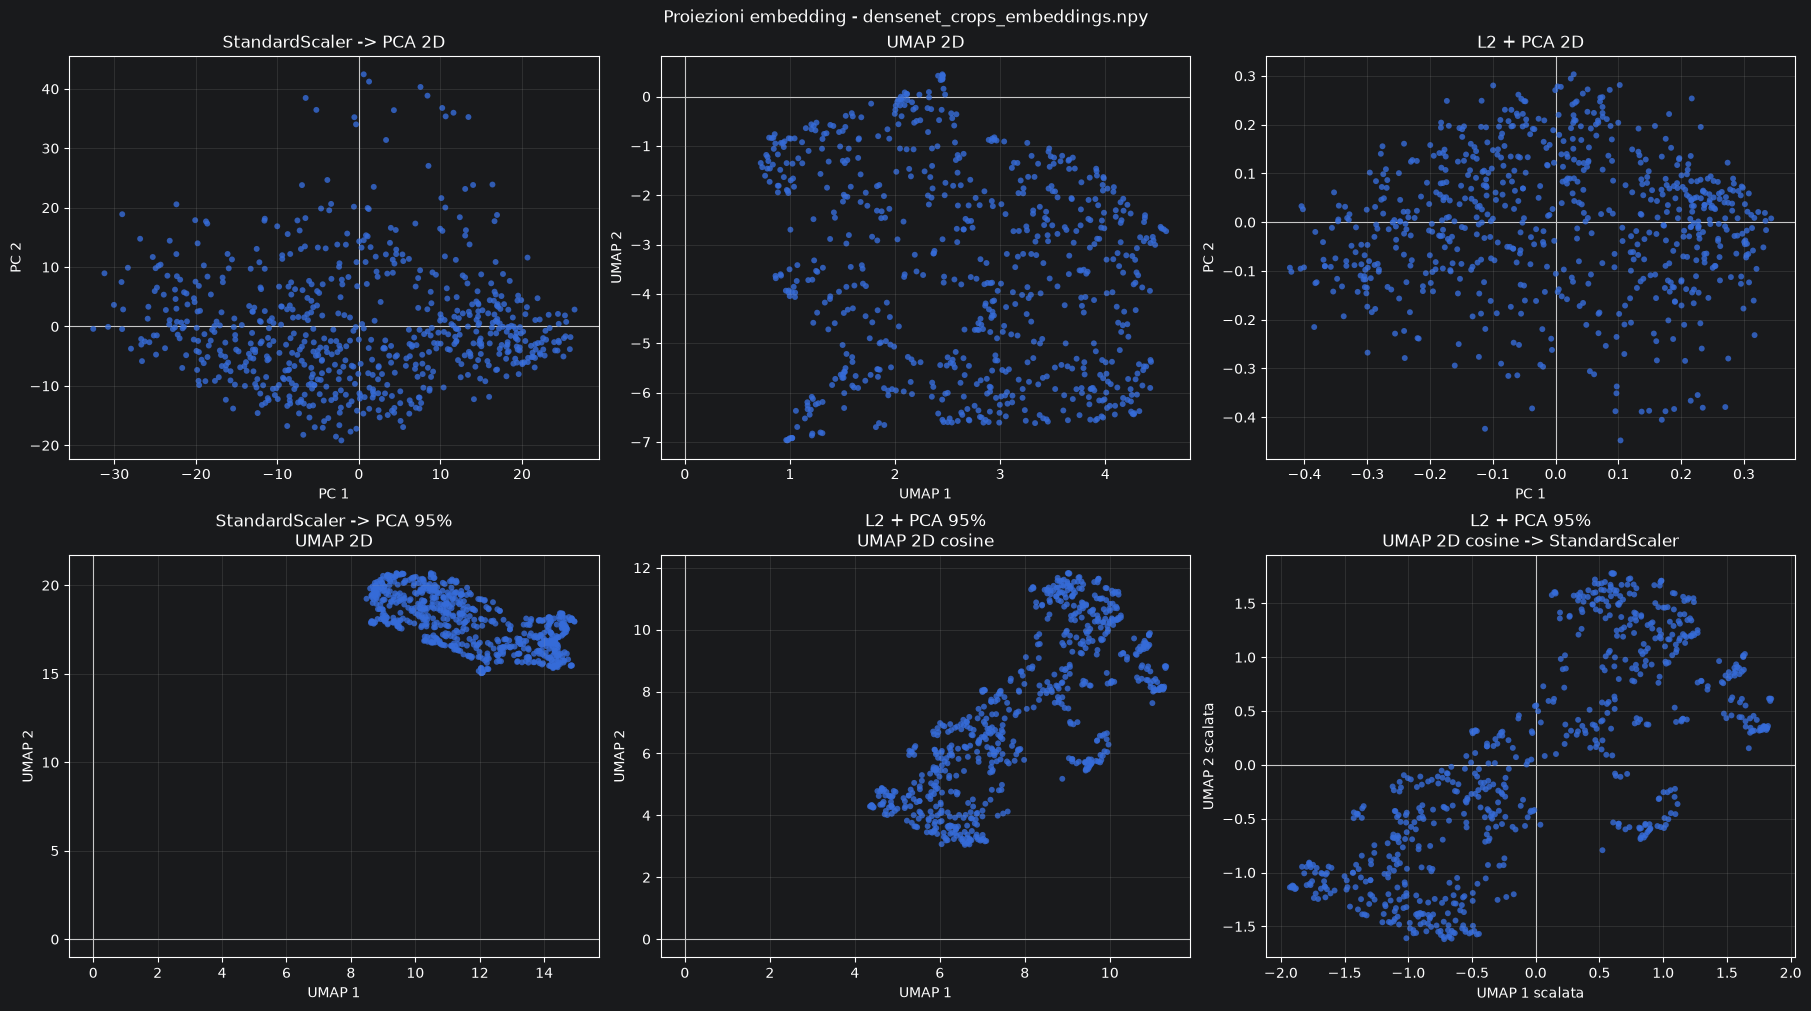

In [32]:
projections = [
    (
        "StandardScaler -> PCA 2D",
        projection_pca_2d,
        "PC 1",
        "PC 2",
    ),
    (
        "UMAP 2D",
        umap_2d,
        "UMAP 1",
        "UMAP 2",
    ),
    (
        "L2 + PCA 2D",
        projection_l2_pca_2d,
        "PC 1",
        "PC 2",
    ),
    (
        "StandardScaler -> PCA 95%\nUMAP 2D",
        umap_after_pca_95,
        "UMAP 1",
        "UMAP 2",
    ),
    (
        "L2 + PCA 95%\nUMAP 2D cosine",
        umap_after_l2_pca_95_cosine,
        "UMAP 1",
        "UMAP 2",
    ),
    (
        "L2 + PCA 95%\nUMAP 2D cosine -> StandardScaler",
        projection_l2_pca_95_umap_cosine_scaled,
        "UMAP 1 scalata",
        "UMAP 2 scalata",
    ),
]

figure, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for axis, (title, coordinates, xlabel, ylabel) in zip(axes.ravel(), projections):
    axis.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        s=18,
        alpha=0.8,
        edgecolors="none",
    )
    axis.axhline(0, color="0.8", linewidth=0.8, zorder=0)
    axis.axvline(0, color="0.8", linewidth=0.8, zorder=0)
    axis.set_title(title)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.2)

figure.suptitle(f"Proiezioni embedding - {embedding_path.name}")
plt.show()